In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
STORY_NAMES = ["Jaguar Knight", "Goldilocks", "Hansel and Gretel", "Jack and the Beanstalk", "Little Red Riding Hood"]

In [3]:
def bar_plot(df, x_col, stds=None, title="", xlabel="", ylabel=""):
    """
    Plots a bar chart with optional error bars.

    Parameters:
    - df (pd.Series): Mean values to plot (e.g., story_action_means).
    - x_col (list): Labels for the x-axis (e.g., story names).
    - stds (pd.Series, optional): Standard deviations for error bars.
    - title (str): Title of the plot.
    - xlabel (str): Label for the x-axis.
    - ylabel (str): Label for the y-axis.
    """
    x = range(len(df))
    
    plt.figure(figsize=(10, 6))
    plt.bar(x, df.values, yerr=stds.values if stds is not None else None, capsize=5)
    plt.xticks(ticks=x, labels=x_col, rotation=45, ha="right")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(1,5)
    plt.tight_layout()
    plt.show()


In [4]:
# Get latest csv file in `results` directory
import os
import glob
path = os.path.join('results', '*.csv')
files = glob.glob(path)
latest_file = max(files, key=os.path.getctime)
# Read the latest csv file

df = pd.read_csv(latest_file, header=None, skiprows=1)
df.columns = df.iloc[0]
df = df[df['Response Type'] == '0']
df = df.iloc[:, 17:158]
df = df.astype(np.int64, errors='ignore')
df = df.apply(pd.to_numeric, errors='coerce')
df

,How strongly do you agree with the following statement?\n\nThe listed actions accurately reflect the plot of the story.,"Before Princess heals Jaguar Knight, it is likely that Princess likes Jaguar Knight.","Before Princess heals Jaguar Knight, Jaguar Knight caused Jaguar Knight's health to be at risk.","After Princess heals Jaguar Knight, it is likely that Jaguar Knight really likes Princess.","After Princess heals Jaguar Knight, Jaguar Knight causes Jaguar Knight's health returns to normal.","Before Enemy kidnaps Princess, it is likely that Enemy hates Princess.","Before Enemy kidnaps Princess, Princess has caused Princess to be a prisoner.","After Enemy kidnaps Princess, it is likely that Princess hates Enemy.","Before Enemy ties up Princess, it is likely that Enemy hates Princess.","Before Enemy ties up Princess, Princess has caused Princess to be a prisoner.",...,"After Grandmother falls ill, Grandmother has caused Grandmother's health to be at risk.","After Wolf hides identity from Grandmother, it is likely that Wolf hates Grandmother.","After Grandmother unknowingly lets Wolf enter, it is likely that Wolf hates Grandmother.","After Wolf eats up Grandmother, nobody has caused Grandmother to die.","After Wolf hides in bed, anybody has caused anybody's life to be at risk.","After Little Red Riding Hood communicates with Wolf, nobody has caused Wolf's life to be at risk.","After Little Red Riding Hood notices something unusual about Wolf, it is likely that Little Red Riding Hood dislikes Wolf.","After Little Red Riding Hood comments on Wolf's appearance, it is likely that Little Red Riding Hood hates Wolf.","After Wolf reveals true identity, anybody has caused anybody's life to be at risk.","After Wolf eats up Little Red Riding Hood, nobody has caused Little Red Riding Hood to die."
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,3.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Overall mean
df.stack().mean(axis=0, skipna=True)

np.float64(3.0637837837837836)

In [6]:
# Mean score of how well actions describe story for each story
df.filter(like="The listed actions accurately reflect the plot of the story.").stack().mean(axis=0, skipna=True)

np.float64(3.5833333333333335)

In [7]:
story_action_means = df.filter(like="The listed actions accurately reflect the plot of the story.").mean(axis=0, skipna=True)
story_action_stds = df.filter(like="The listed actions accurately reflect the plot of the story.").std(axis=0, skipna=True)

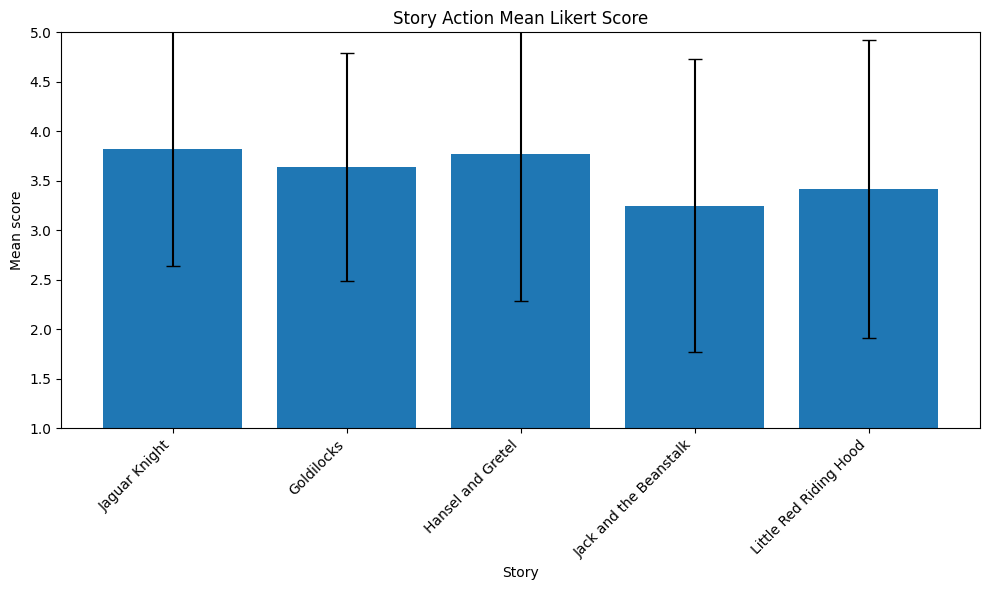

In [8]:
bar_plot(
    df=story_action_means,
    x_col=STORY_NAMES,
    stds=story_action_stds,
    title="Story Action Mean Likert Score",
    xlabel="Story",
    ylabel="Mean score"
)


In [17]:
precondition_means = df.filter(like="Before").stack().mean(axis=0, skipna=True)
precondition_stds = df.filter(like="Before").stack().std(axis=0, skipna=True)
precondition_means, precondition_stds

(np.float64(3.1307420494699647), np.float64(1.568938910718323))

In [10]:
postcondition_means = df.filter(like="After").stack().mean(axis=0, skipna=True)
postcondition_stds = df.filter(like="After").stack().std(axis=0, skipna=True)
postcondition_means, postcondition_stds

(np.float64(2.9649122807017543), np.float64(1.4323026096388531))

In [11]:
target_value = "The listed actions accurately reflect the plot of the story."
story_indices = [i for  i, val in enumerate(df.columns) if target_value in val] 
story_indices.append(158)
story_indices

[0, 35, 47, 101, 122, 158]

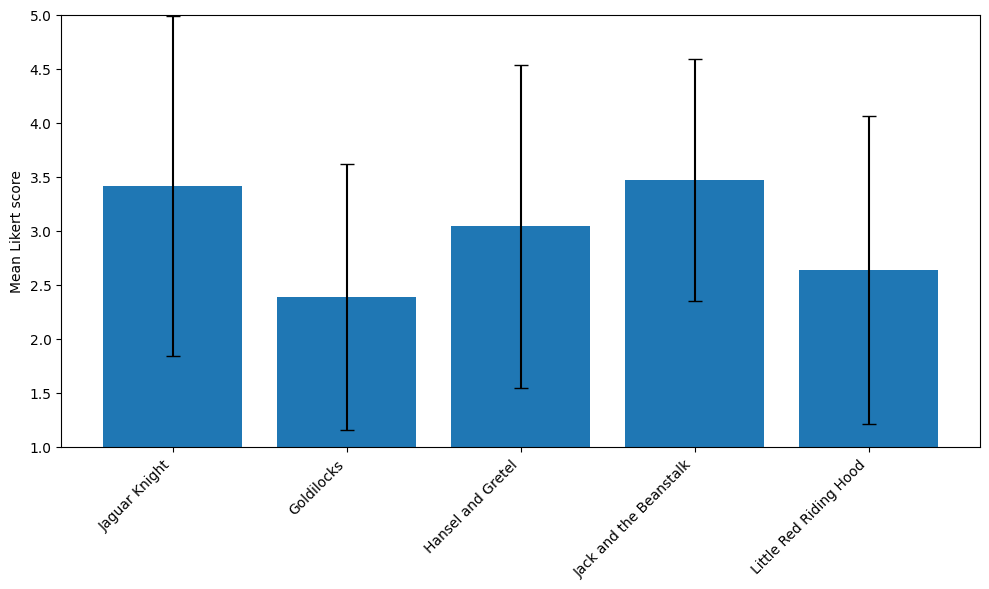

In [20]:
story_means = []
story_stds = []
for i in range(len(story_indices)-1):
    story_means.append(df.iloc[:, story_indices[i]:story_indices[i+1]].stack().mean(axis=0, skipna=True))
    story_stds.append(df.iloc[:, story_indices[i]:story_indices[i+1]].stack().std(axis=0, skipna=True))
story_means = pd.Series(story_means, index=STORY_NAMES)
story_stds = pd.Series(story_stds, index=STORY_NAMES)
bar_plot(
    df=story_means,
    x_col=STORY_NAMES,
    stds=story_stds,
    title="",
    ylabel="Mean Likert score"
)

In [21]:
story_means, story_stds

(Jaguar Knight             3.413115
 Goldilocks                2.386905
 Hansel and Gretel         3.040816
 Jack and the Beanstalk    3.467213
 Little Red Riding Hood    2.635294
 dtype: float64,
 Jaguar Knight             1.568551
 Goldilocks                1.228044
 Hansel and Gretel         1.492594
 Jack and the Beanstalk    1.122162
 Little Red Riding Hood    1.421326
 dtype: float64)

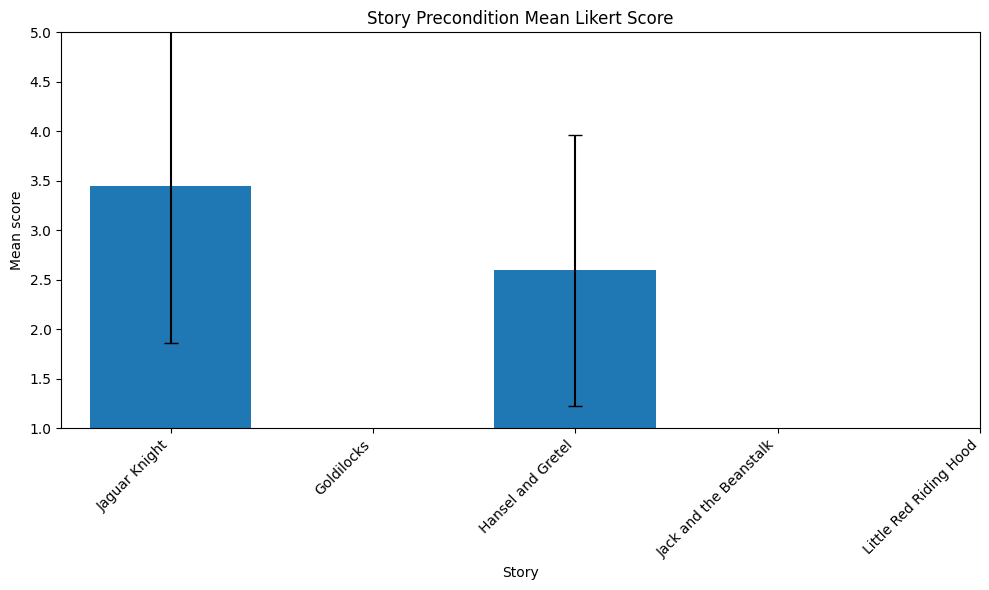

In [13]:
story_pre_means = []
story_pre_stds = []
for i in range(len(story_indices)-1):
    story_pre_means.append(df.iloc[:, story_indices[i]:story_indices[i+1]].filter(like="Before").stack().mean(axis=0, skipna=True))
    story_pre_stds.append(df.iloc[:, story_indices[i]:story_indices[i+1]].filter(like="Before").stack().std(axis=0, skipna=True))
story_pre_means = pd.Series(story_pre_means, index=STORY_NAMES)
story_pre_stds = pd.Series(story_pre_stds, index=STORY_NAMES)
bar_plot(
    df=story_pre_means,
    x_col=STORY_NAMES,
    stds=story_pre_stds,
    title="Story Precondition Mean Likert Score",
    xlabel="Story",
    ylabel="Mean score"
)

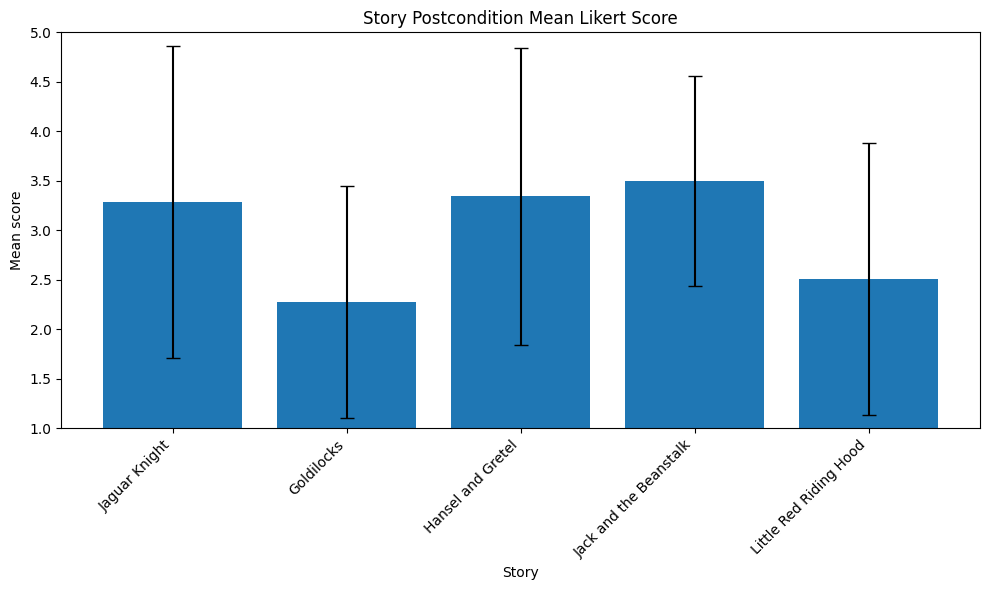

In [14]:
story_post_means = []
story_post_stds = []
for i in range(len(story_indices)-1):
    story_post_means.append(df.iloc[:, story_indices[i]:story_indices[i+1]].filter(like="After").stack().mean(axis=0, skipna=True))
    story_post_stds.append(df.iloc[:, story_indices[i]:story_indices[i+1]].filter(like="After").stack().std(axis=0, skipna=True))
story_post_means = pd.Series(story_post_means, index=STORY_NAMES)
story_post_stds = pd.Series(story_post_stds, index=STORY_NAMES)
bar_plot(
    df=story_post_means,
    x_col=STORY_NAMES,
    stds=story_post_stds,
    title="Story Postcondition Mean Likert Score",
    xlabel="Story",
    ylabel="Mean score"
)

In [15]:
table = pd.DataFrame({
    ("Action", "Mean"): story_action_means.values,
    ("Action", "Std"): story_action_stds.values,
    ("Precondition", "Mean"): story_pre_means.values,
    ("Precondition", "Std"): story_pre_stds.values,
    ("Postcondition", "Mean"): story_post_means.values,
    ("Postcondition", "Std"): story_post_stds.values
}, index=STORY_NAMES)
table = table.round(2)
table

Action       Precondition       Postcondition      
                         Mean   Std         Mean   Std          Mean   Std
Jaguar Knight            3.82  1.19         3.45  1.60          3.29  1.57
Goldilocks               3.64  1.15          NaN   NaN          2.27  1.17
Hansel and Gretel        3.77  1.48         2.59  1.37          3.34  1.50
Jack and the Beanstalk   3.25  1.48          NaN   NaN          3.50  1.06
Little Red Riding Hood   3.42  1.51          NaN   NaN          2.51  1.38

In [16]:
table.to_csv("charts/story_pre_post_condition_means.csv")